In [ ]:
#import all tools
import numpy as np
import pandas as pd
import scanpy as sc
import scrublet as scr
import scipy.io
import matplotlib.pyplot as plt
import os
import bbknn as bk
import scvelo as scv

In [ ]:
#directory
adata=sc.read_h5ad('data/all2_filter3_trim2.h5ad')

In [ ]:
adata.obs_names

In [ ]:
adata.obs.columns

In [ ]:
#annotations for cellsMI
adata
anno = pd.read_csv("data/corrAnno.csv")
anno1=anno['Cells']
anno1 = np.asarray(anno1)
adata.obs['Cells']=anno1
anno2=anno['cellsMI']
anno2 = np.asarray(anno2)
adata.obs['cellsMI']=anno2

In [ ]:
#load custom annotations and add it to adata
anno = pd.read_csv("data/obs.csv")
anno1=anno['sample_batch']
anno1 = np.asarray(anno1)
adata.obs['sample_batch']=anno1

In [ ]:
#Actb counts
adata.X[:,adata.var.index == 'Actb']

In [ ]:
#pca and bbknn
sc.tl.pca(adata, svd_solver='arpack')
bk.bbknn(adata)
sc.tl.umap(adata)
sc.settings.set_figure_params(dpi=300,fontsize=10)

In [ ]:
#to read in the fibroblasts previously saved to home
fibroblasts = sc.read_h5ad('data/fibroblasts.h5ad')

In [ ]:
sc.settings.set_figure_params(dpi=300,fontsize=10)

In [ ]:
#isolate fibroblasts
fibroblasts = adata[adata.obs['Cells']=='Fibroblasts']
results_file = 'data/fibroblasts.h5ad'
fibroblasts.write(results_file)

In [ ]:
results_file = 'data/fibroblasts.h5ad'

In [ ]:
#pca and bbknn
sc.tl.pca(fibroblasts, svd_solver='arpack')
bk.bbknn(fibroblasts)
sc.tl.umap(fibroblasts)

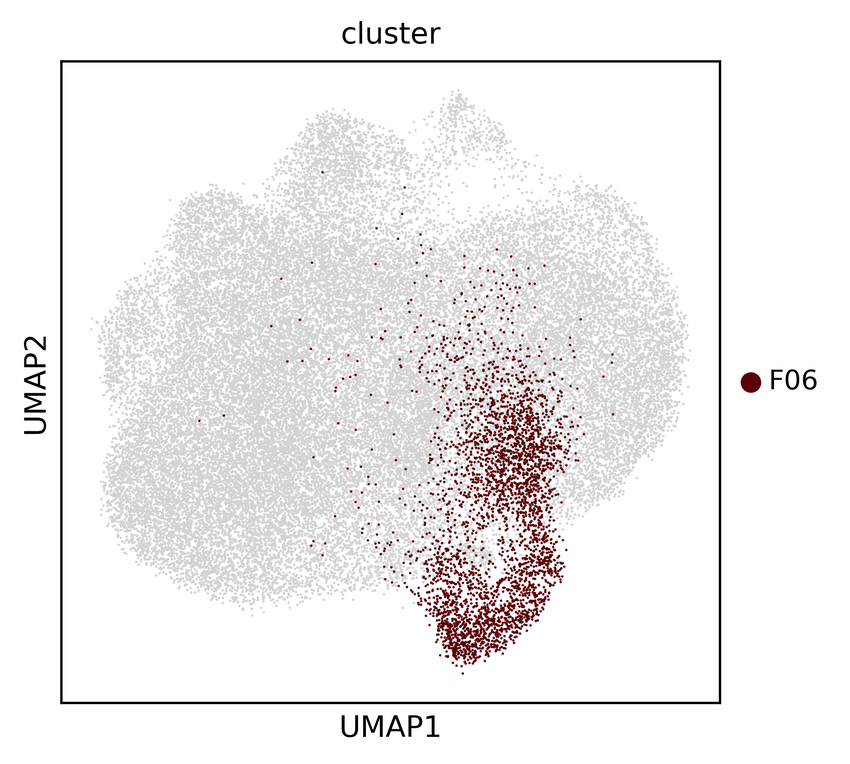

In [ ]:
#colour specific groups/fibroblast clusters only
sc.tl.leiden(fibroblasts,resolution=0.9,n_iterations=-1)
sc.pl.umap(fibroblasts,color='cluster',groups='F06')

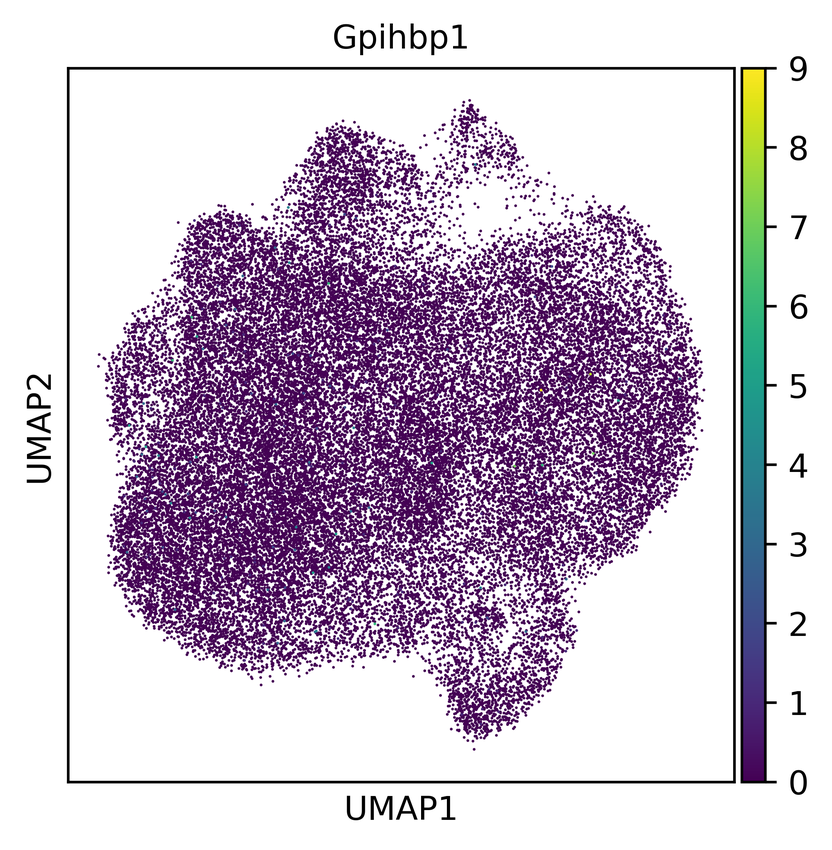

In [ ]:
sc.pl.umap(fibroblasts,color='Gpihbp1', use_raw= True)

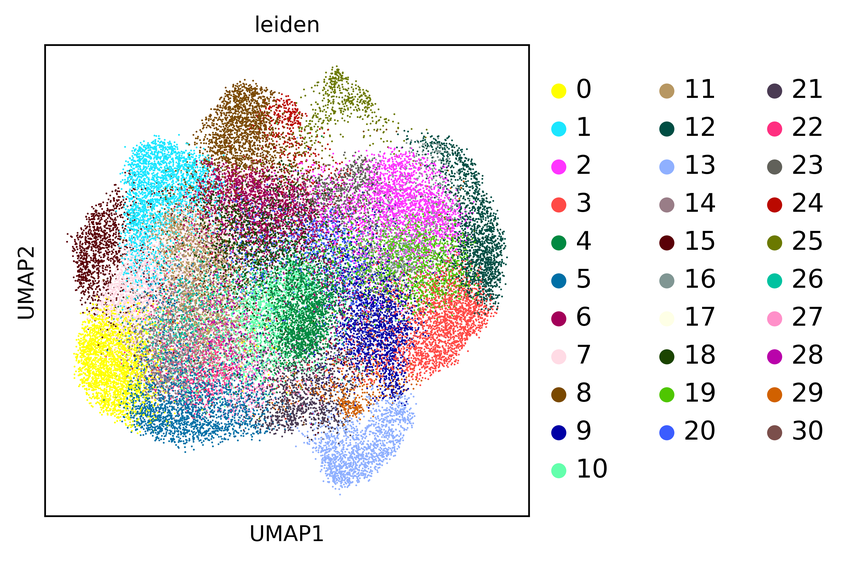

In [ ]:
#optimal cluster number is 14 with res 0.9
#but cluster number 31 with res 2 could be good 
#change resolution accordingly
sc.tl.leiden(fibroblasts,resolution=2,n_iterations=-1)
sc.pl.umap(fibroblasts,color='leiden',legend_fontsize='large')

In [ ]:
fibroblasts.write_csvs(results_file[:-5],)

In [ ]:
anno = pd.read_csv("data/res2clusters.csv",sep=";")
anno1=anno['res2']
anno1 = np.asarray(anno1)
adata.obs['res2']=anno1

In [ ]:
anno = pd.read_csv("data/res2clusters.csv",sep=";")
anno1=anno['res2MI']
anno1 = np.asarray(anno1)
adata.obs['res2MI']=anno1

In [ ]:
results_file

In [ ]:
adatafile = 'data/adata.h5ad'
adata.write(adatafile)

In [ ]:
D01 = adata[adata.obs['MI']=='D01']
D01file = 'data/D01.h5ad'
D01.write(D01file)

In [ ]:
D03 = adata[adata.obs['MI']=='D03']
D03file = 'data/D03.h5ad'
D03.write(D03file)

In [ ]:
D07 = adata[adata.obs['MI']=='D07']
D07file = 'data/D07.h5ad'
D07.write(D07file)

In [ ]:
D30 = adata[adata.obs['MI']=='D30']
D30file = 'data/D30.h5ad'
D30.write(D30file)

In [ ]:
Sham = adata[adata.obs['MI']=='Sham']
Shamfile = 'data/Sham.h5ad'
Sham.write(Shamfile)

In [ ]:
Unop = adata[adata.obs['MI']=='Unop']
Unopfile = 'data/Unop.h5ad'
Unop.write(Unopfile)

In [ ]:
adata.X

In [ ]:
D01.X=np.expm1(D01.X)
D01.obs['cell_ids']=D01.obs.index
D01.norm=D01.X
D01.raw=D01
df_expr_matrix = D01.norm 
df_expr_matrix = df_expr_matrix.T
df_expr_matrix = pd.DataFrame(df_expr_matrix)
df_expr_matrix.columns = D01.obs.index
df_expr_matrix.set_index(D01.raw.var.index, inplace=True)

#steps necessary for mouse data
index=pd.Series(df_expr_matrix.index)
index=index.str.upper()
df_expr_matrix.set_index(index, inplace=True) 

#resume steps
df_expr_matrix.to_csv('data/counts_D01.txt',sep='\t')
df_meta = pd.DataFrame(data={'Cell': list(D01.obs['cell_ids']), 
                             'cell_type': list(D01.obs['res2MI'])})
df_meta.set_index('Cell',inplace=True)
df_meta.to_csv('data/meta_D01.txt', sep='\t')

In [ ]:
D03.X=np.expm1(D03.X)
D03.obs['cell_ids']=D03.obs.index
D03.norm=D03.X
D03.raw=D03
df_expr_matrix = D03.norm 
df_expr_matrix = df_expr_matrix.T
df_expr_matrix = pd.DataFrame(df_expr_matrix)
df_expr_matrix.columns = D03.obs.index
df_expr_matrix.set_index(D03.raw.var.index, inplace=True)

#steps necessary for mouse data
index=pd.Series(df_expr_matrix.index)
index=index.str.upper()
df_expr_matrix.set_index(index, inplace=True) 

#resume steps
df_expr_matrix.to_csv('data/counts_D03.txt',sep='\t')
df_meta = pd.DataFrame(data={'Cell': list(D03.obs['cell_ids']), 
                             'cell_type': list(D03.obs['res2MI'])})
df_meta.set_index('Cell',inplace=True)
df_meta.to_csv('data/meta_D03.txt', sep='\t')

In [ ]:
D07.X=np.expm1(D07.X)
D07.obs['cell_ids']=D07.obs.index
D07.norm=D07.X
D07.raw=D07
df_expr_matrix = D07.norm 
df_expr_matrix = df_expr_matrix.T
df_expr_matrix = pd.DataFrame(df_expr_matrix)
df_expr_matrix.columns = D07.obs.index
df_expr_matrix.set_index(D07.raw.var.index, inplace=True)

#steps necessary for mouse data
index=pd.Series(df_expr_matrix.index)
index=index.str.upper()
df_expr_matrix.set_index(index, inplace=True) 

#resume steps
df_expr_matrix.to_csv('data/counts_D07.txt',sep='\t')
df_meta = pd.DataFrame(data={'Cell': list(D07.obs['cell_ids']), 
                             'cell_type': list(D07.obs['res2MI'])})
df_meta.set_index('Cell',inplace=True)
df_meta.to_csv('data/meta_D07.txt', sep='\t')

In [ ]:
D30.X=np.expm1(D30.X)
D30.obs['cell_ids']=D30.obs.index
D30.norm=D30.X
D30.raw=D30
df_expr_matrix = D30.norm 
df_expr_matrix = df_expr_matrix.T
df_expr_matrix = pd.DataFrame(df_expr_matrix)
df_expr_matrix.columns = D30.obs.index
df_expr_matrix.set_index(D30.raw.var.index, inplace=True)

#steps necessary for mouse data
index=pd.Series(df_expr_matrix.index)
index=index.str.upper()
df_expr_matrix.set_index(index, inplace=True) 

#resume steps
df_expr_matrix.to_csv('data/counts_D30.txt',sep='\t')
df_meta = pd.DataFrame(data={'Cell': list(D30.obs['cell_ids']), 
                             'cell_type': list(D30.obs['res2MI'])})
df_meta.set_index('Cell',inplace=True)
df_meta.to_csv('data/meta_D30.txt', sep='\t')

In [ ]:
Sham.X=np.expm1(Sham.X)
Sham.obs['cell_ids']=Sham.obs.index
Sham.norm=Sham.X
Sham.raw=Sham
df_expr_matrix = Sham.norm 
df_expr_matrix = df_expr_matrix.T
df_expr_matrix = pd.DataFrame(df_expr_matrix)
df_expr_matrix.columns = Sham.obs.index
df_expr_matrix.set_index(Sham.raw.var.index, inplace=True)

#steps necessary for mouse data
index=pd.Series(df_expr_matrix.index)
index=index.str.upper()
df_expr_matrix.set_index(index, inplace=True) 

#resume steps
df_expr_matrix.to_csv('data/counts_Sham.txt',sep='\t')
df_meta = pd.DataFrame(data={'Cell': list(Sham.obs['cell_ids']), 
                             'cell_type': list(Sham.obs['res2MI'])})
df_meta.set_index('Cell',inplace=True)
df_meta.to_csv('data/meta_Sham.txt', sep='\t')

In [ ]:
Unop.X=np.expm1(Unop.X)
Unop.obs['cell_ids']=Unop.obs.index
Unop.norm=Unop.X
Unop.raw=Unop
df_expr_matrix = Unop.norm 
df_expr_matrix = df_expr_matrix.T
df_expr_matrix = pd.DataFrame(df_expr_matrix)
df_expr_matrix.columns = Unop.obs.index
df_expr_matrix.set_index(Unop.raw.var.index, inplace=True)

#steps necessary for mouse data
index=pd.Series(df_expr_matrix.index)
index=index.str.upper()
df_expr_matrix.set_index(index, inplace=True) 

#resume steps
df_expr_matrix.to_csv('data/counts_Unop.txt',sep='\t')
df_meta = pd.DataFrame(data={'Cell': list(Unop.obs['cell_ids']), 
                             'cell_type': list(Unop.obs['res2MI'])})
df_meta.set_index('Cell',inplace=True)
df_meta.to_csv('data/meta_Unop.txt', sep='\t')

In [ ]:
#CH score calculation
import sklearn
CH_scores = []
resolutions = np.arange(0.2,3,0.1)

sc.tl.umap(fibroblasts,n_components=20, random_state=123)
bk.bbknn(fibroblasts,use_rep='X_umap', n_pcs=20)
for res in resolutions:
    sc.tl.leiden(fibroblasts,resolution = res,n_iterations=-1, random_state=123)
    score = sklearn.metrics.calinski_harabasz_score(fibroblasts.obsm['X_umap'],fibroblasts.obs['leiden'])
    CH_scores.append(score)
    print(score)

In [ ]:
np.arange(0.2,3,0.1)

In [ ]:
fibroblasts.obs['leiden']

In [ ]:
print(CH_scores)

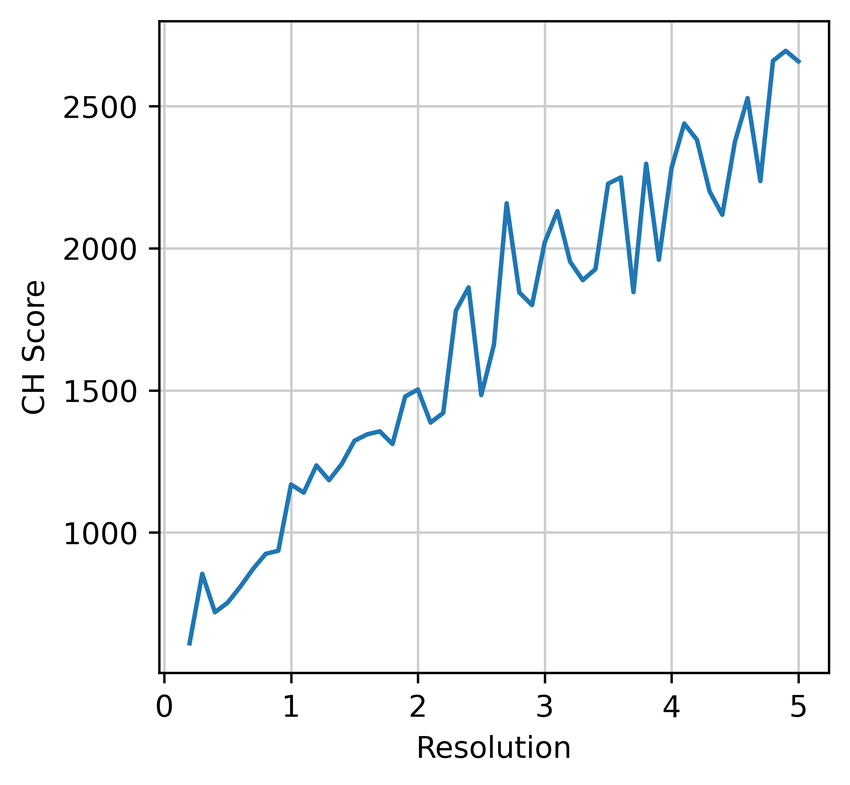

In [ ]:
import matplotlib
from matplotlib import pyplot as plt
plt.plot(resolutions, CH_scores)
plt.xlabel("Resolution")
plt.ylabel("CH Score")

In [ ]:
sc.tl.dendrogram(fibroblasts,groupby='leiden')

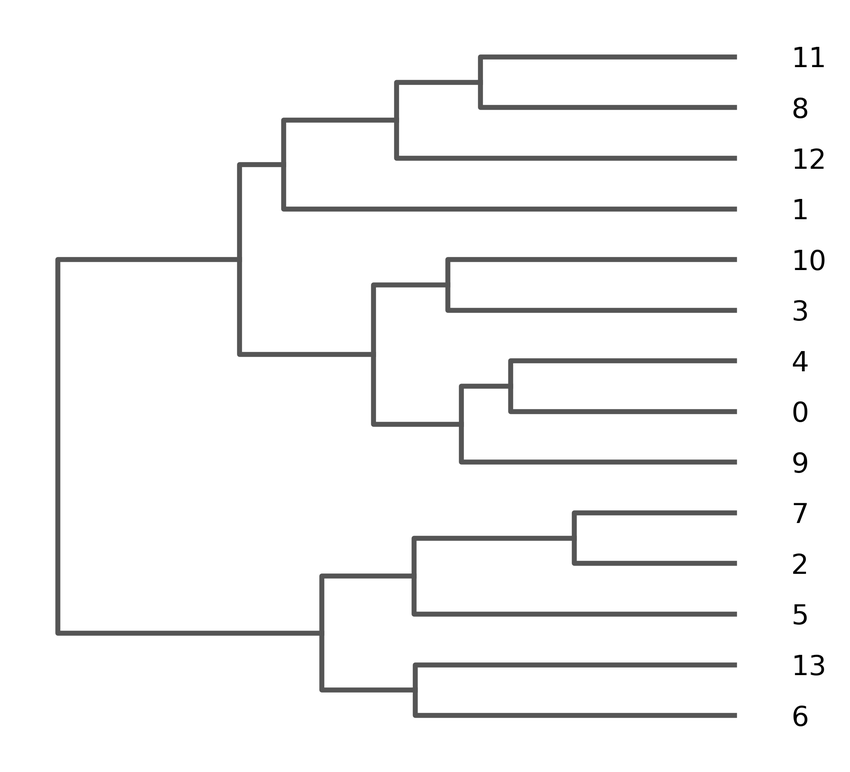

In [ ]:
#dendrogram same as dotplot dendrogram
sc.pl.dendrogram(fibroblasts,groupby='leiden', ax = plt.subplot(111), show = True, orientation = 'left')

In [ ]:
#number of cells at bottom
fibroblasts.obs.leiden

In [ ]:
import matplotlib
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
#hierarchical clustering part 1
clusters = list(set(fibroblasts.obs['leiden']))
cluster_means = np.empty([len(clusters), 50], dtype='float32')

for i, cluster in enumerate(clusters):
    cluster_mask = fibroblasts.obs['leiden'] == cluster
    points_in_cluster = fibroblasts.obsm['X_umap'][cluster_mask]
    mean_cluster_point = np.mean(points_in_cluster, axis=0)
    cluster_means[i] = mean_cluster_point

In [ ]:
#hierarchical clustering part 2
#Z = linkage(cluster_means, method = 'ward')
plt.figure(figsize=(10,7))
plt.title('Hierarchical Clustering Dendrogram')
plt.ylabel('distance (Ward)')
plt.xlabel('cluster number')
dendo = dendrogram(fibroblasts.uns['dendrogram_leiden'].get('linkage'), leaf_rotation=90)

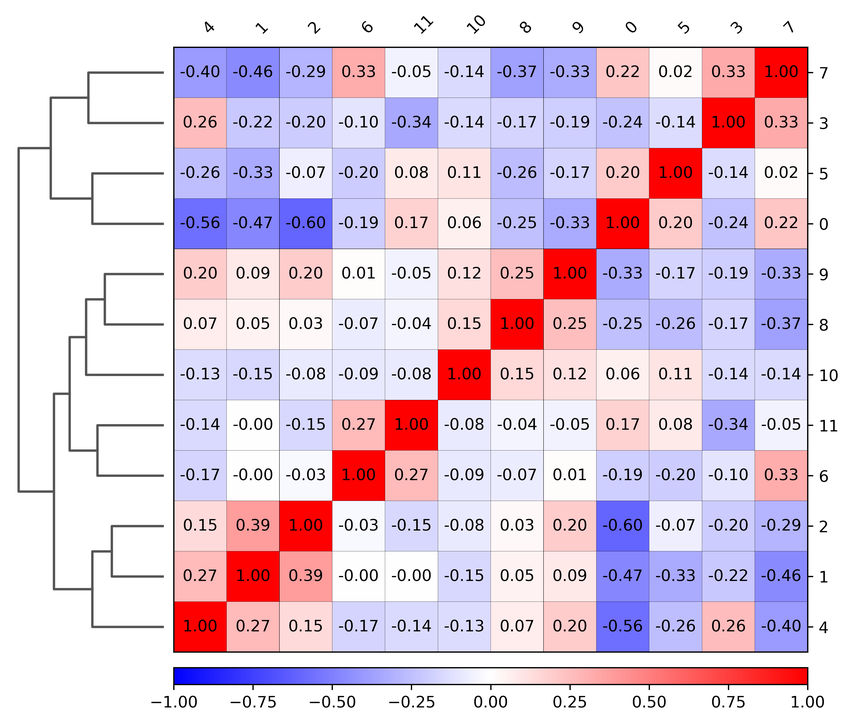

In [ ]:
sc.pl.correlation_matrix(fibroblasts,groupby='leiden',show_correlation_numbers=True)

In [ ]:
corrmat = fibroblasts.uns['dendrogram_leiden']['correlation_matrix']
scorelist = []
for item in corrmat:
    score = sum(item)/len(item)
    scorelist.append(score)
    print(score)

In [ ]:
print(scorelist)

In [ ]:
fibroblasts.obs_names

In [ ]:
import sklearn

In [ ]:
sklearn.metrics.silhouette_score(fibroblasts,n_labels=2,n_samples=-1,metric='euclidean',sample_size=None,random_state=None)

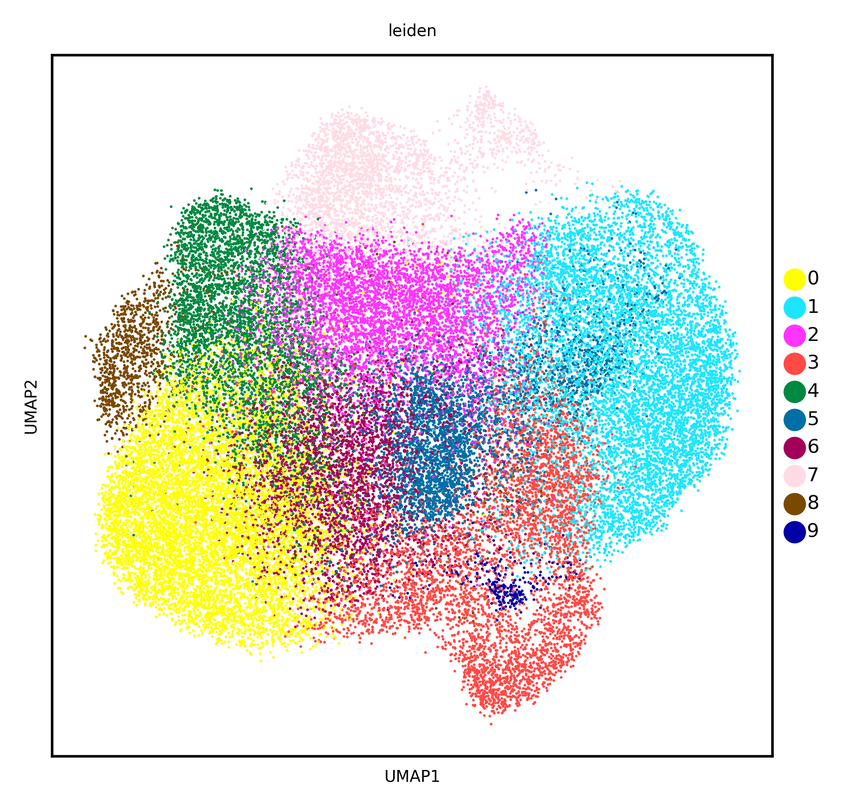

In [ ]:
#for testing labelling of clusters on umap for harvey and skelly data
#cluster number 10 with res 0.63
sc.tl.leiden(fibroblasts,resolution=0.63,n_iterations=-1)
sc.pl.umap(fibroblasts,color='leiden',legend_fontsize='large')

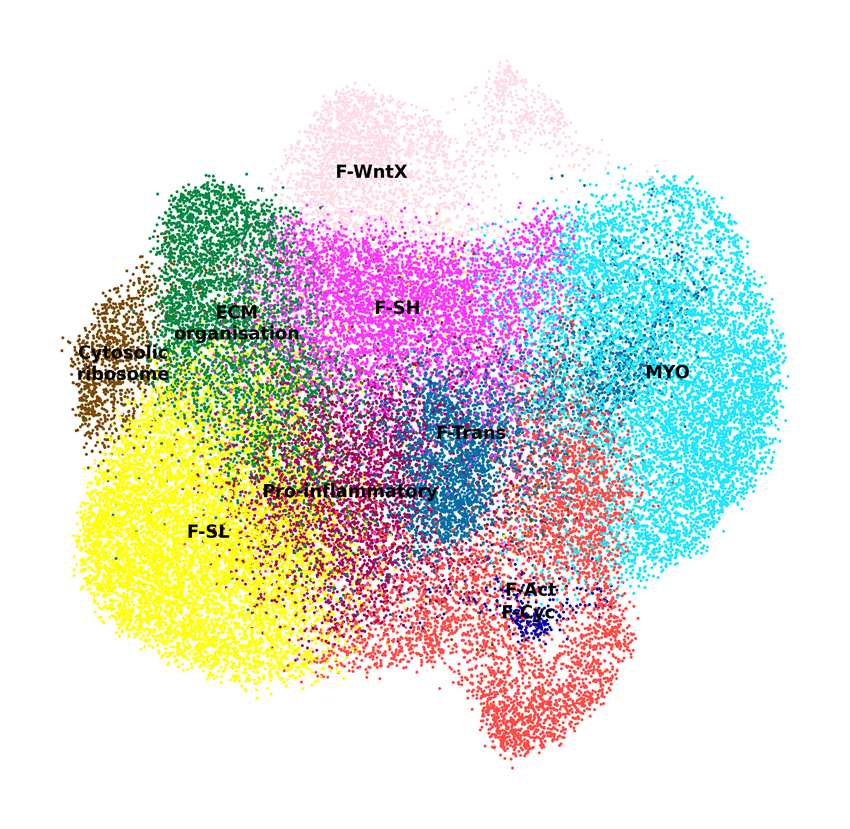

In [ ]:
sc.settings.set_figure_params(dpi=300,fontsize=5)
new_cluster_names = [
    'F-SL', 'MYO',
    'F-SH', 'F-Act',
    'ECM\norganisation', 'F-Trans',
    'Pro-inflammatory', 'F-WntX', 'Cytosolic\nribosome', 'F-Cyc']
fibroblasts.rename_categories('leiden', new_cluster_names)
sc.pl.umap(fibroblasts, color='leiden', legend_loc='on data', title='', frameon=False)

In [ ]:
#load markers
marker = pd.read_csv("data/ligands.csv")

In [ ]:
marker=marker['Name'] 
marker_genes = np.asarray(marker)

In [ ]:
# testing logistic regression model with random data

import statsmodels.api as sm

np.random.seed(123)
random_data = np.random.choice([0,1], size=500, p=[0.8,0.2])
random_target = np.random.choice([0,1], size=500, p=[0.5,0.5])

random_data = random_data.reshape(-1,1)

logistic_regression_model = sm.GLM(random_target, random_data, family=sm.families.Binomial())
logistic_regression_model = logistic_regression_model.fit()
logistic_regression_model.pvalues < 0.05

In [ ]:
adata.shape

In [ ]:
import statsmodels.api as sm

# this is a function for identifying genes whose drop-out events are associated with clusters
def identify_biased_genes(AnnData, labels):
    
    biased_genes = []
    
    # loop through cluster labels
    for label in labels:
        
        # identify cells that are in each cluster (each cell is a 1 if in, 0 if out)
        in_cluster_mask = labels == label
        in_cluster_var = in_cluster_mask.astype(int)    
        
        # loop through genes, get expression for each gene, and build logistic regression model to predict gene expression from cluster membership
        # flag genes whose expressions have highly significant association with the cluster (p < 0.05)
        for i, gene in enumerate(AnnData.var.index):
        
            gene_expression = np.flat(AnnData.X[:,i])
            target_var = np.zeroes(len(gene_expression))
            target_var[gene_expression > 0] = 1
        
            logistic_regression_model = sm.GLM(in_cluster_var, gene_expression, family=sm.families.Binomial())
            logistic_regression_model = logistic_regression_model.fit()
            
            # if pvalue less than 0.05 add gene to the list of biased genes
            if logistic_regression_model.pvalues < 0.05:
                biased_genes.append(gene)
                
    return(biased_genes)

In [ ]:
sc.tl.rank_genes_groups(fibroblasts,groupby='leiden',n_genes=3,method='t-test',corr_method='bonferroni')

In [ ]:
for gene1, gene2, gene3 in fibroblasts.uns['rank_genes_groups']['names'][:,]:
    print(gene1, gene2, gene3)

In [ ]:
sc.tl.rank_genes_groups(fibroblasts, 'leiden', method = 'wilcoxon', n_genes = 500, use_raw = True)
result = fibroblasts.uns['rank_genes_groups']
groups = result['names'].dtype.names
markers = pd.DataFrame(
{group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals_adj', 'logfoldchanges','scores']})
markers.head(10)

In [ ]:
sc.tl.dendrogram(fibroblasts,groupby='leiden')

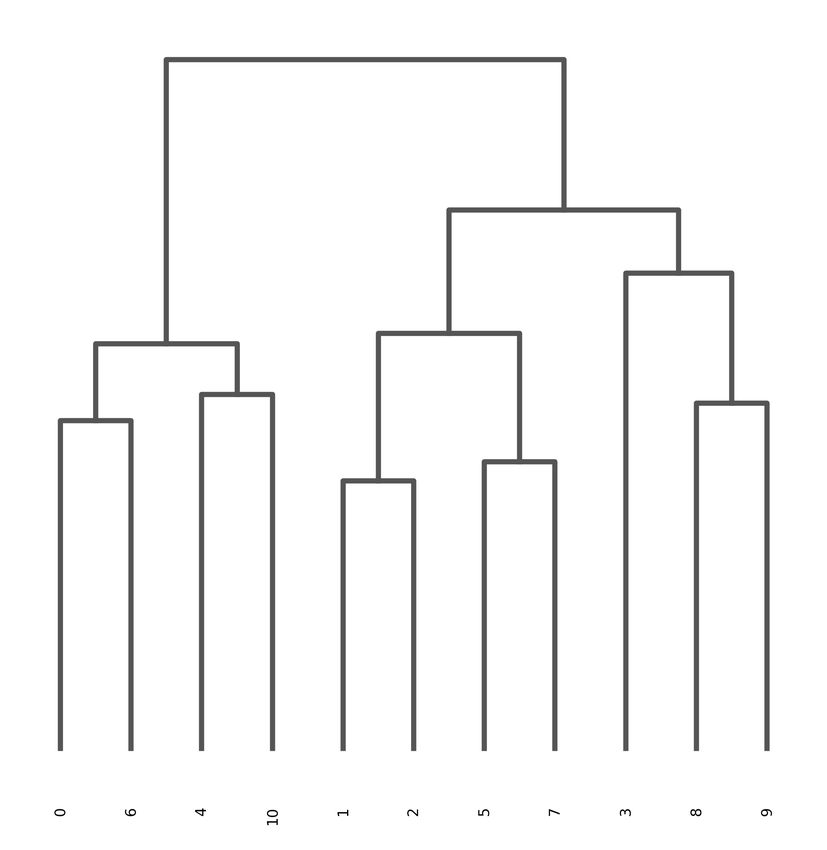

In [ ]:
sc.pl.dendrogram(fibroblasts,groupby='leiden')

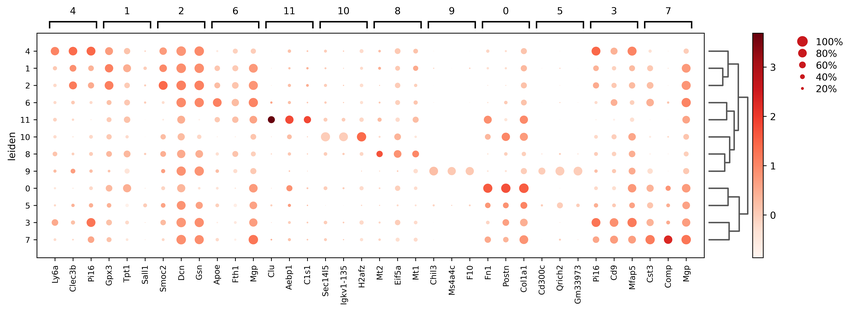

In [ ]:
sc.pl.rank_genes_groups_dotplot(fibroblasts,n_genes=3)

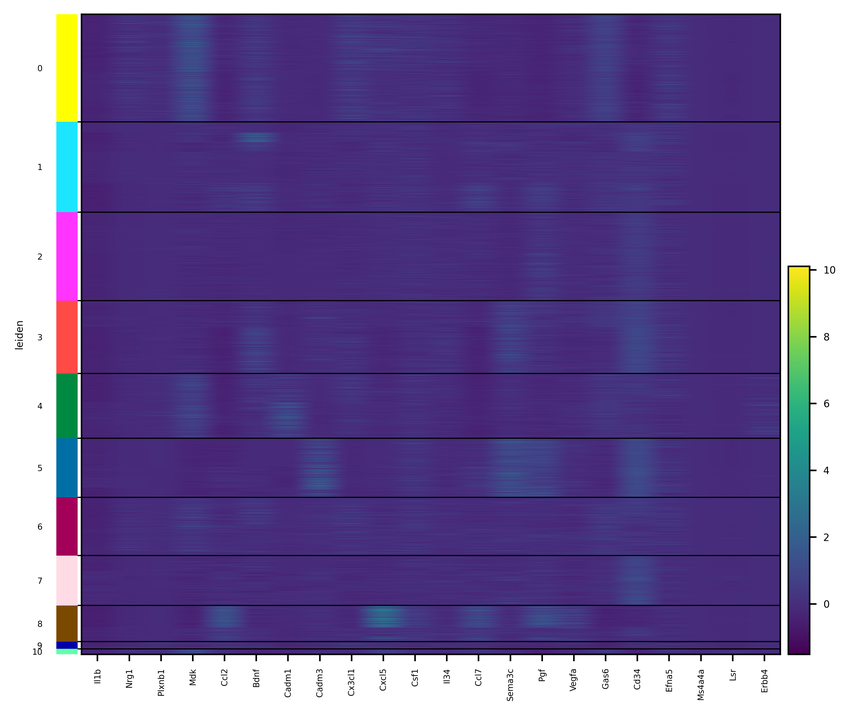

In [ ]:
sc.pl.heatmap(fibroblasts,marker_genes,groupby='leiden')

In [ ]:
sc.tl.rank_genes_groups(fibroblasts,groupby='leiden',n_genes=10,method='logreg',corr_method='bonferroni')

In [ ]:
sc.tl.dendrogram(fibroblasts,groupby='leiden')

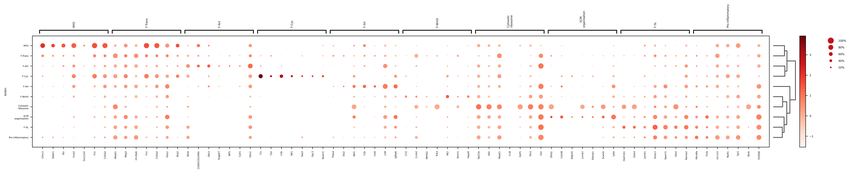

In [ ]:
sc.pl.rank_genes_groups_dotplot(fibroblasts,n_genes=7)

In [ ]:
#to isolate unoperated data only to compare basal expression levels of Wif1 across batches as they should be the same
#only noseda and skelly have unoperated data 
adata.obs['MI']

In [ ]:
#now we know unoperated is called unop
#isolate unop
unop = fibroblasts[fibroblasts.obs['MI']=='Unop']
results_file = 'data/unop.h5ad'
unop.write(results_file)

In [ ]:
sc.tl.pca(unop, svd_solver='arpack')

In [ ]:
#for unoperated noseda only
unopnoseda = unop[unop.obs['batch']== 'Noseda']
results_file = 'data/unopnoseda.h5ad'
unopnoseda.write(results_file)

In [ ]:
fibroblasts.uns['dendrogram_leiden']['linkage']

In [ ]:
#for unoperated skelly only
unopskelly = unop[unop.obs['batch']=='Skelly']
results_file = 'data/unopskelly.h5ad'
unopskelly.write(results_file)

In [ ]:
print(unopskelly)

In [ ]:
#how many cells out of unop express Wif1
arr = unop[:, 'Wif1'].X > 0
np.flatnonzero(arr).size

In [ ]:
adata.var.loc['Wif1',:]

In [ ]:
wif1_mask = unopnoseda.var.index == 'Wif1'
np.flatnonzero(unopnoseda.X[:,wif1_mask] > 0).size

In [ ]:
wif1_mask = unopskelly.var.index == 'Wif1'
np.flatnonzero(unopskelly.X[:,wif1_mask] > 0).size

In [ ]:
unopskelly.var.loc['Wif1','n_cells']

In [ ]:
fibroblasts.obs['n_counts']

In [ ]:
wif1_expression = unop[:,'Wif1'].X

In [ ]:
wif1_expression = unop[:,'Wif1'].obs['n_counts']
wif1_expression
#pd.crosstab(unop.obs['batch'], unop.obs['Wif1'])

In [ ]:
fibroblasts.obs['batch']

In [ ]:
fibroblasts.obs['clusters'].value_counts()

In [ ]:
for col in fibroblasts.obs.columns:
    print(col)

In [ ]:
table = pd.crosstab(unop.obs['batch'], unop.obs['MI'])
table.columns = pd.Index(list(table.columns))

In [ ]:
table['Wif1_cells']= [61, 381]
table['Percentage_%'] = [3.22, 5.54]

In [ ]:
table

In [ ]:
#clustersMI dotplots
sc.tl.leiden(fibroblasts, resolution=0.9, n_iterations=-1, random_state = 0)
sc.tl.rank_genes_groups(fibroblasts,groupby='clustersMI',n_genes=10,method='logreg',corr_method='bonferroni')

In [ ]:
sc.tl.dendrogram(fibroblasts,groupby='leiden')

In [ ]:
sc.pl.rank_genes_groups_dotplot(fibroblasts,n_genes=5)

In [ ]:
sc.pl.heatmap(fibroblasts,marker_genes,groupby='leiden')

In [ ]:
sc.pl.rank_genes_groups_dotplot(fibroblasts,n_genes=10)

In [ ]:
pip install git+git://github.com/Maayanlab/geode.git

In [ ]:
#consensus clustering
range_of_resolutions = np.arange(0.1,1,0.1)
consensus_clustering = LeidenCluster().consensus_cluster(sp, 'resolution', range_of_resolutions)